In [1]:
import os
import argparse

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F




class VAE(nn.Module):
    def __init__(self, latent_dim: int = 20):
        super().__init__()
        # Encoder
        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28 * 28)  # logits (no sigmoid here)

    def encode(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        return mu , log_var

    def reparameterize(self, mu, logvar):
      eps = torch.randn_like(mu)
      z = mu  + torch.exp(0.5 * logvar) * eps


    def decode(self, z):

        return self.fc4(F.relu(self.fc3(z)))

    def forward(self, x):
        mu , log_var= self.encode(x)
        z = self.reparameterize(mu , log_var)
        return self.decode(z)


def vae_loss(logits, x, mu, logvar):
    """
    ELBO = E_q[log p(x|z)] - KL(q(z|x)||p(z))
    We minimize: recon_loss + KL
    For MNIST, p(x|z) as Bernoulli => recon_loss = BCE.
    """
    # Reconstruction loss (sum over pixels and batch)
    bce = F.binary_cross_entropy_with_logits(logits , x)
    # KL divergence between q(z|x)=N(mu, diag(exp(logvar))) and p(z)=N(0, I)
    kl =  - 0.5 * torch.sum(mu**2 + torch.exp(logvar) - 1 - logvar)

    return bce + kl, bce, kl

IndentationError: expected an indented block after function definition on line 24 (3657006932.py, line 27)

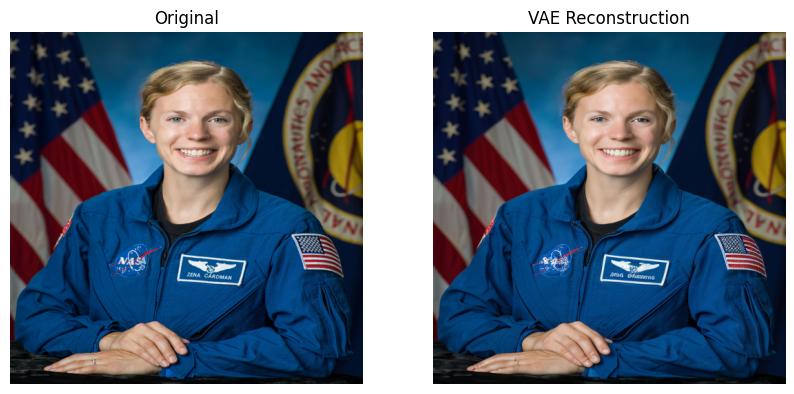

In [ ]:
# pip install -q diffusers transformers accelerate safetensors torch pillow matplotlib

import torch
import numpy as np
from diffusers import AutoencoderKL
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse",
    torch_dtype=dtype
).to(device)

# Load local image instead of URL
image = Image.open("Zena_Cardman_official_portrait.jpg").convert("RGB").resize((512, 512))

# PIL -> tensor in [0,1]
x = np.array(image).astype("float32") / 255.0
x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device, dtype=dtype)

# Scale to [-1,1] for the VAE
x = x * 2 - 1

with torch.no_grad():
    posterior = vae.encode(x).latent_dist
    z = posterior.sample()
    x_rec = vae.decode(z).sample

orig = ((x[0].float().cpu() + 1) / 2).permute(1, 2, 0).clamp(0, 1).numpy()
rec  = ((x_rec[0].float().cpu() + 1) / 2).permute(1, 2, 0).clamp(0, 1).numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rec)
plt.title("VAE Reconstruction")
plt.axis("off")
plt.show()